# **Importing Libraries**

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [47]:
df = pd.read_csv('bank-additional-full.csv' , sep = ';')

In [48]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


#Output
* yes → customer subscribed to term deposit
* no  → customer did not subscribe

In [49]:
df.shape

(41188, 21)

In [50]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [52]:
df['y'].value_counts()

,count
y,
no,36548
yes,4640


#**EDA (Exploratory Data Analysis)**

In [53]:
df['job'].value_counts()

,count
job,
admin.,10422
blue-collar,9254
technician,6743
services,3969
management,2924
retired,1720
entrepreneur,1456
self-employed,1421
housemaid,1060


In [54]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


job:
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']

marital:
['married' 'single' 'divorced' 'unknown']

education:
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']

default:
['no' 'unknown' 'yes']

housing:
['no' 'yes' 'unknown']

loan:
['no' 'yes' 'unknown']

contact:
['telephone' 'cellular']

month:
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']

day_of_week:
['mon' 'tue' 'wed' 'thu' 'fri']

poutcome:
['nonexistent' 'failure' 'success']

y:
['no' 'yes']


In [55]:
pd.crosstab(
    df['job'],
    df['y'],
    normalize='index'
) * 100

y,no,yes
job,,
admin.,87.027442,12.972558
blue-collar,93.105684,6.894316
entrepreneur,91.483516,8.516484
housemaid,90.000000,10.000000
management,88.782490,11.217510
retired,74.767442,25.232558
self-employed,89.514426,10.485574
services,91.861930,8.138070
student,68.571429,31.428571


In [56]:
pd.crosstab(
    df['marital'],
    df['y'],
    normalize='index'
) * 100

y,no,yes
marital,,
divorced,89.679098,10.320902
married,89.842747,10.157253
single,85.995851,14.004149
unknown,85.000000,15.000000


In [57]:
pd.crosstab(
    df['education'],
    df['y'],
    normalize='index'
) * 100

y,no,yes
education,,
basic.4y,89.750958,10.249042
basic.6y,91.797557,8.202443
basic.9y,92.175352,7.824648
high.school,89.164477,10.835523
illiterate,77.777778,22.222222
professional.course,88.651535,11.348465
university.degree,86.275477,13.724523
unknown,85.499711,14.500289


In [58]:
df['education'].value_counts()

,count
education,
university.degree,12168
high.school,9515
basic.9y,6045
professional.course,5243
basic.4y,4176
basic.6y,2292
unknown,1731
illiterate,18


In [59]:
pd.crosstab(
    df['default'],
    df['y'],
    normalize='index'
) * 100

y,no,yes
default,,
no,87.121026,12.878974
unknown,94.847040,5.152960
yes,100.000000,0.000000


In [60]:
df['default'].value_counts()

,count
default,
no,32588
unknown,8597
yes,3


In [61]:
pd.crosstab(
    df['housing'],
    df['y'],
    normalize='index'
) * 100

y,no,yes
housing,,
no,89.120395,10.879605
unknown,89.191919,10.808081
yes,88.380608,11.619392


In [62]:
pd.crosstab(
    df['loan'],
    df['y'],
    normalize='index'
) * 100

y,no,yes
loan,,
no,88.659794,11.340206
unknown,89.191919,10.808081
yes,89.068502,10.931498


In [63]:
pd.crosstab(
    df['contact'],
    df['y'],
    normalize='index'
) * 100

y,no,yes
contact,,
cellular,85.262393,14.737607
telephone,94.768679,5.231321


In [64]:
pd.crosstab(
    df['month'],
    df['y'],
    normalize='index'
) * 100

y,no,yes
month,,
apr,79.521277,20.478723
aug,89.397863,10.602137
dec,51.098901,48.901099
jul,90.953443,9.046557
jun,89.488530,10.511470
mar,49.450549,50.549451
may,93.565255,6.434745
nov,89.856133,10.143867
oct,56.128134,43.871866


In [65]:
pd.crosstab(
    df['day_of_week'],
    df['y'],
    normalize='index'
) * 100

y,no,yes
day_of_week,,
fri,89.191261,10.808739
mon,90.051680,9.948320
thu,87.881248,12.118752
tue,88.220025,11.779975
wed,88.332924,11.667076


In [66]:
pd.crosstab(
    df['poutcome'],
    df['y'],
    normalize='index'
) * 100

y,no,yes
poutcome,,
failure,85.771402,14.228598
nonexistent,91.167787,8.832213
success,34.887109,65.112891


# Categorical EDA Observation

Overall, categorical analysis shows that features such as job, education, month, contact, and especially poutcome have noticeable relationships with the subscription outcome. marital, housing, loan, and day_of_week show comparatively weaker differences. The categorical features will therefore be retained and appropriately encoded before model training.

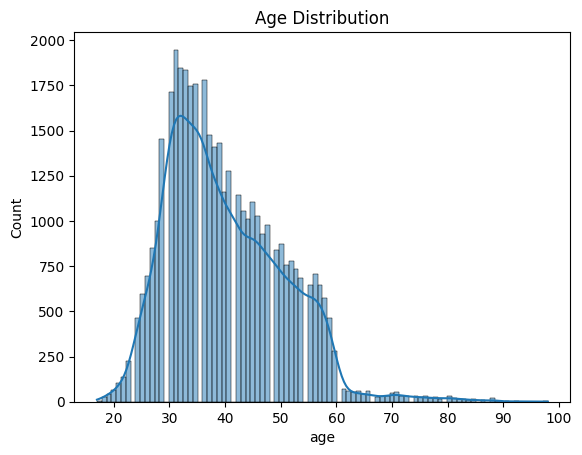

In [67]:
sns.histplot(data=df, x='age', kde=True)
plt.title('Age Distribution')
plt.show()

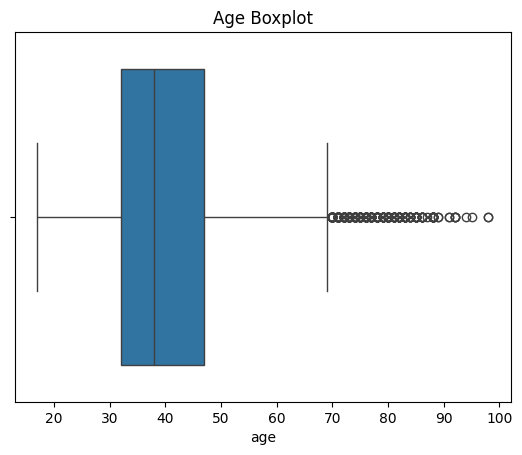

In [68]:
sns.boxplot(data=df, x='age')
plt.title('Age Boxplot')
plt.show()

In [69]:
df['age'].describe()

,age
count,41188.00000
mean,40.02406
std,10.42125
min,17.00000
25%,32.00000
50%,38.00000
75%,47.00000
max,98.00000


In [70]:
df['age'].skew()

np.float64(0.7846968157646645)

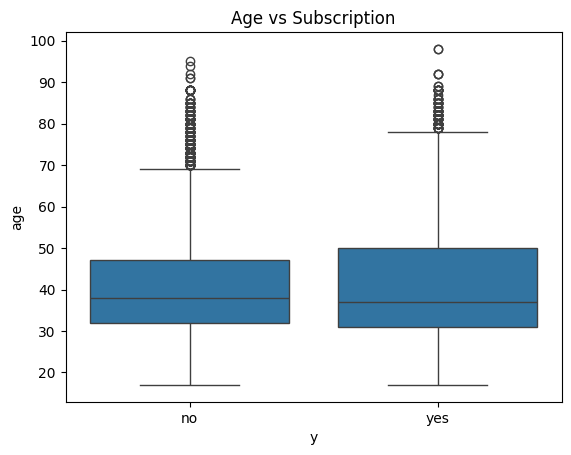

In [71]:
sns.boxplot(data=df, x='y', y='age')
plt.title('Age vs Subscription')
plt.show()

In [72]:
df.groupby('y')['age'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
y,,,,
no,39.911185,38.0,17,95
yes,40.913147,37.0,17,98


Age has some relationship with the target, but the distributions of both classes overlap heavily. Therefore, age is likely useful as a supporting feature rather than a strong standalone predictor.

In [73]:
df["duration"].describe()

,duration
count,41188.000000
mean,258.285010
std,259.279249
min,0.000000
25%,102.000000
50%,180.000000
75%,319.000000
max,4918.000000


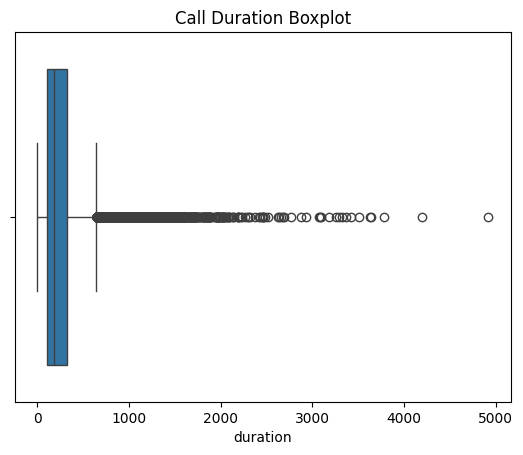

In [74]:
sns.boxplot(x=df["duration"])
plt.title("Call Duration Boxplot")
plt.show()

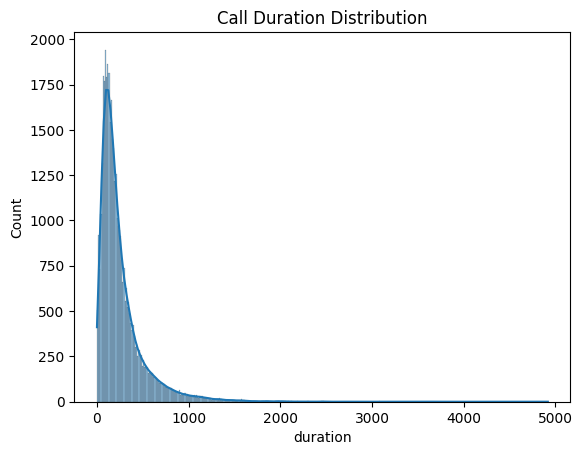

In [75]:
sns.histplot(df["duration"], kde=True)
plt.title("Call Duration Distribution")
plt.show()

In [76]:
df.groupby("y")["duration"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
y,,,,
no,220.844807,163.5,0,4918
yes,553.191164,449.0,37,4199


In [77]:
df = df.drop(columns=['duration'])
df['y'] = df['y'].map({'no': 0, 'yes': 1})
df['y'].value_counts()

,count
y,
0,36548
1,4640


In [78]:
df['pdays'] = df['pdays'].replace(999, np.nan)

In [79]:
df['pdays_missing'] = df['pdays'].isna().astype(int)

In [80]:
df['pdays'] = df['pdays'].fillna(df['pdays'].median())

In [81]:
categorical_cols = df.select_dtypes(include='object').columns

categorical_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

In [82]:
categorical_cols = df.select_dtypes(include='object').columns

categorical_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

In [83]:
df['housing'] = df['housing'].map({
    'no': 0,
    'yes': 1,
    'unknown': np.nan
})

df['loan'] = df['loan'].map({
    'no': 0,
    'yes': 1,
    'unknown': np.nan
})

df['contact'] = df['contact'].map({
    'cellular': 0,
    'telephone': 1
})

#**Encoding**

In [84]:
categorical_cols = [
    'job', 'marital', 'education', 'default',
    'housing', 'loan', 'contact', 'month',
    'day_of_week', 'poutcome'
]

for col in categorical_cols:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=True, dtype=int)
    df = pd.concat([df, dummies], axis=1)
    df.drop(col, axis=1, inplace=True)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 52 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            41188 non-null  int64  
 1   campaign                       41188 non-null  int64  
 2   pdays                          41188 non-null  float64
 3   previous                       41188 non-null  int64  
 4   emp.var.rate                   41188 non-null  float64
 5   cons.price.idx                 41188 non-null  float64
 6   cons.conf.idx                  41188 non-null  float64
 7   euribor3m                      41188 non-null  float64
 8   nr.employed                    41188 non-null  float64
 9   y                              41188 non-null  int64  
 10  pdays_missing                  41188 non-null  int64  
 11  job_blue-collar                41188 non-null  int64  
 12  job_entrepreneur               41188 non-null 

#**Train-Test-Split**

In [86]:
X = df.drop('y', axis=1)
y = df['y']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(32950, 51)
(8238, 51)


#**Scaling**

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#**Logistic Regression**

In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_LR = LogisticRegression(max_iter=1000)

model_LR.fit(X_train_scaled, y_train)

y_prediction_LR = model_LR.predict(X_test_scaled)

accuracy_LR = accuracy_score(y_test, y_prediction_LR)

print("Accuracy:", accuracy_LR)

Accuracy: 0.9010682204418549


#**KNN (K-Nearest Neighbors)**

In [89]:
from sklearn.neighbors import KNeighborsClassifier

model_KNN = KNeighborsClassifier()

model_KNN.fit(X_train_scaled, y_train)

y_prediction_KNN = model_KNN.predict(X_test_scaled)

accuracy_KNN = accuracy_score(y_test, y_prediction_KNN)

print("Accuracy:", accuracy_KNN)

Accuracy: 0.8958485069191552


#**SVM (Support Vector Machine)**

In [90]:
from sklearn.svm import LinearSVC

model_SVM = LinearSVC(max_iter=5000, random_state=42)

model_SVM.fit(X_train_scaled, y_train)

y_prediction_SVM = model_SVM.predict(X_test_scaled)

accuracy_SVM = accuracy_score(y_test, y_prediction_SVM)

print("Accuracy:", accuracy_SVM)

Accuracy: 0.9014323865015781


#**Naive bayes**

In [91]:
from sklearn.naive_bayes import GaussianNB

model_NB = GaussianNB()

model_NB.fit(X_train_scaled, y_train)

y_prediction_NB = model_NB.predict(X_test_scaled)

accuracy_NB = accuracy_score(y_test, y_prediction_NB)

print("Accuracy:", accuracy_NB)

Accuracy: 0.7563729060451566


#**Decision Tree**

In [92]:
from sklearn.tree import DecisionTreeClassifier

model_DT = DecisionTreeClassifier(random_state=42)

model_DT.fit(X_train, y_train)

y_prediction_DT = model_DT.predict(X_test)

accuracy_DT = accuracy_score(y_test, y_prediction_DT)

print("Accuracy:", accuracy_DT)

Accuracy: 0.8413449866472444


#**Random Forest**

In [93]:
from sklearn.ensemble import RandomForestClassifier

model_RF = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_RF.fit(X_train, y_train)

y_prediction_RF = model_RF.predict(X_test)

accuracy_RF = accuracy_score(y_test, y_prediction_RF)

print("Accuracy:", accuracy_RF)

Accuracy: 0.8948773974265598


#**Classification Report**

# SVM

In [94]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_prediction_SVM))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.72      0.21      0.32       928

    accuracy                           0.90      8238
   macro avg       0.81      0.60      0.63      8238
weighted avg       0.89      0.90      0.88      8238



# LR

In [95]:
print(classification_report(y_test, y_prediction_LR))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.69      0.22      0.34       928

    accuracy                           0.90      8238
   macro avg       0.80      0.61      0.64      8238
weighted avg       0.88      0.90      0.88      8238



[[7216   94]
 [ 721  207]]


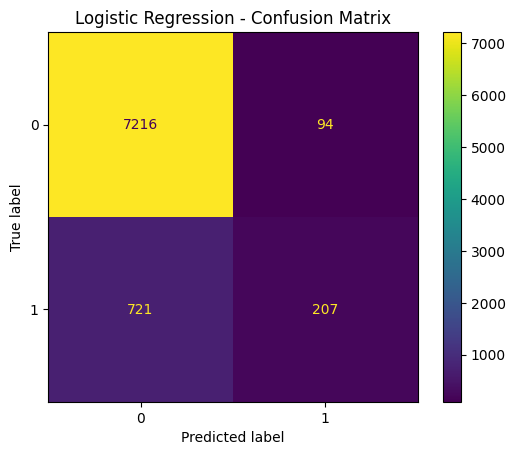

In [96]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_prediction_LR)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# **Conclusion**

# Overall, I learned how to take the Bank Marketing dataset from the initial data cleaning stage to model evaluation. I worked with the categorical features, encoded them, split the data into training and testing sets, scaled the required features, and compared different classification models.

# SVM gave the highest accuracy of around 90.14%, but after checking the confusion matrix and classification report, I found that the model was not performing equally well for the yes class. This helped me understand that accuracy alone is not enough, especially when the dataset is imbalanced. Metrics like precision, recall, and F1-score give a better idea of how well the model is actually performing.